In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pprint
from scipy.stats import chi2_contingency, fisher_exact, ttest_ind, ttest_rel, pointbiserialr, pearsonr
from IPython.display import display, HTML
from pathlib import Path

import os
import sys
import analysis_utility_funcs as unified_funcs # ---- this worked because of the new pyproject.toml file, and we ran 'pip install -e .' in the conda env setup script, which runs the pyproject.toml, which basically makes any (root-level) cross-folder imports work without needing to mess with sys.path. So I can import python scripts if I want from src, run_annotation, archive, whichever.

## The complete annotated Franken dataset in a dataframe:
- ### TWO intensities : mild ("mild_harm_mild_good") and severe ("severe_harm_very_good")
- ### Within each, EIGHT causal conditions : CC/COC (i.e. means/side-effect) x In/Evitability x Action/Prevention (i.e. commission/omission)
- ### Each causal condition contains TEN annotated scenarios, SID goes from 0-9 within each.
- ### Therefore, we get 80 mild and 80 severe scenarios totalling 160 annotated scenarios.
- ### Each scenario generates multiple (5-10) events, each event gets its own row. So total row count is 800+.

#### META-NOTE: I am currently re-running Franken through the annotator using 1) the latest state of the annotator as well as 2) using the entire set of scenarios. 

#### The current set of scenarios used above are 80 total for severe (10 in each causal condition) and 80 total for mild (10 in each causal condition).

#### The FULL set is actually 80 total for severe and 400 total for mild (50 in each causal condition). That should give us more statistical power; all that is needed is to drop in the new results, and the dataframe-making/analysis notebooks work the same. Will need to re-do primary harm event picking though...

In [2]:
all_FRANKEN_df = []

intensities = ["mild_harm_mild_good", "severe_harm_very_good"]
causal_conditions = ["cc_evitable_action_yes_stories", "cc_evitable_prevention_no_stories", "cc_inevitable_action_yes_stories", "cc_inevitable_prevention_no_stories", "coc_evitable_action_yes_stories", "coc_evitable_prevention_no_stories", "coc_inevitable_action_yes_stories", "coc_inevitable_prevention_no_stories"]

for intensity in intensities:
    for causal_condition in causal_conditions:
        df = unified_funcs.read_all_scenarios(f"../../scenarios_inputs/franken/conditions_{intensity}/{causal_condition}.json", f"../../annotated_outputs/franken_o1o2/conditions_{intensity}/{causal_condition}/")
        all_FRANKEN_df.append(df)
        # SPECIAL - add the intensity and causal_condition as columns to the dataframe
        all_FRANKEN_df[-1]["intensity"] = intensity
        all_FRANKEN_df[-1]["causal_condition"] = causal_condition
all_FRANKEN_df = pd.concat(all_FRANKEN_df, ignore_index=True)
# sort the intensity column by the order of the intensities in the intensities list above
all_FRANKEN_df["intensity"] = pd.Categorical(all_FRANKEN_df["intensity"], categories=intensities, ordered=True)
# sort them by the order of the causal conditions in the causal_conditions list above
all_FRANKEN_df["causal_condition"] = pd.Categorical(all_FRANKEN_df["causal_condition"], categories=causal_conditions, ordered=True)
# sort the dataframe by intensity, then by causal condition, then by SID, then by option --- this is how I think is best to sort it for readability but can be changed up.
all_FRANKEN_df = all_FRANKEN_df.sort_values(by=["intensity","causal_condition", "SID", "option"]).reset_index(drop=True)
# drop all the rows where SID is greater than 9
all_FRANKEN_df = all_FRANKEN_df[all_FRANKEN_df["SID"] <= 9]
display(HTML(all_FRANKEN_df[0:5].to_html()))
print("number of rows in all_FRANKEN_df:", len(all_FRANKEN_df))

,SID,option,event,being,C,I,K,utility,deontic,intensity,causal_condition
0,0,1: renovate the park.,The park closes temporarily,i,+,+,+,"{'residents of the community who use or value the park': '-55', 'i': '0'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories
1,0,1: renovate the park.,Residents lose access to the recreational space during the renovation,i,+,+,+,"{'residents of the community who use or value the park': '-68', 'i': '0'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories
2,0,1: renovate the park.,Residents experience inconvenience,i,+,-,+,"{'residents of the community who use or value the park': '-35', 'i': '0'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories
3,0,1: renovate the park.,Residents experience disappointment,i,+,-,+,"{'residents of the community who use or value the park': '-55', 'i': '-12'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories
4,0,1: renovate the park.,Park facilities are improved,i,+,+,+,"{'residents of the community who use or value the park': '84', 'i': '12'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories


number of rows in all_FRANKEN_df: 754


## Split the dataframe into two, one for mild only and one for severe only.
#### Each dataframe still has eight causal conditions, each having 10 scenarios, 80 total.

In [3]:
mild_FRANKEN_df = all_FRANKEN_df[all_FRANKEN_df["intensity"] == "mild_harm_mild_good"]
severe_FRANKEN_df = all_FRANKEN_df[all_FRANKEN_df["intensity"] == "severe_harm_very_good"]
print("mild_FRANKEN_df preview:")
display(HTML(mild_FRANKEN_df[0:2].to_html()))
print("number of rows in mild_FRANKEN_df:", len(mild_FRANKEN_df))
print("severe_FRANKEN_df preview:")
display(HTML(severe_FRANKEN_df[0:2].to_html()))
print("number of rows in severe_FRANKEN_df:", len(severe_FRANKEN_df))

mild_FRANKEN_df preview:


,SID,option,event,being,C,I,K,utility,deontic,intensity,causal_condition
0,0,1: renovate the park.,The park closes temporarily,i,+,+,+,"{'residents of the community who use or value the park': '-55', 'i': '0'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories
1,0,1: renovate the park.,Residents lose access to the recreational space during the renovation,i,+,+,+,"{'residents of the community who use or value the park': '-68', 'i': '0'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories


number of rows in mild_FRANKEN_df: 309
severe_FRANKEN_df preview:


,SID,option,event,being,C,I,K,utility,deontic,intensity,causal_condition
380,0,1: initiate the major urban renewal project.,Historical buildings are demolished,i,+,+,+,"{'residents of the long-established residential community': '-72', 'i': '0'}",3.0,severe_harm_very_good,cc_evitable_action_yes_stories
381,0,1: initiate the major urban renewal project.,Residents are relocated from the long-established community,i,+,+,+,"{'residents of the long-established residential community': '-88', 'i': '-72'}",3.0,severe_harm_very_good,cc_evitable_action_yes_stories


number of rows in severe_FRANKEN_df: 445


## Shared helpers

- `sig_stars` -- turns a p-value into significance stars.
- `bar_dot_sem` -- bar (mean) + SEM error bars + jittered individual points, for unpaired group comparisons.
- `paired_bar_dot_sem` -- same, but for paired/matched data: draws a thin connecting line between each matched pair of points (e.g. the same scenario's CC vs COC value).
- `per_scenario_proportion` -- collapses an event-level +/- column down to one proportion per scenario (per SID), so that scenario -- not event -- is the unit of analysis.
- `paired_proportion_barplots` -- builds the standard 4-sub-condition + overall 5-panel proportion comparison (used by Analyses 1A, 2, 3), each panel a paired t-test.
- `extract_min_utility` / `extract_max_utility` -- pull the most-negative/most-positive utility score out of a scenario's per-event utility dict (used by Analyses 4, 5A, 5B, 6A). `extract_utility_score` is an alias for `extract_min_utility`, kept for the primary-harm-event picking in 5A/5B.
- `create_utility_bar_dot_plots` -- the 8-causal-condition + overall mild-vs-severe utility comparison grid (used by Analysis 4).
- `perform_t_tests` -- runs the mild-vs-severe one-sided t-test per causal condition + overall (used by Analysis 4).
- `intentionality_by_I_label_plot` -- builds the standard 7-subgroup (CC/COC/Action/Prevention/Evitable/Inevitable/Overall) I+/I- vs avg_intention_rating bar+dot+SEM comparison, with the point-biserial r/p annotated on every panel (used by Analyses 5A, 5B).

In [4]:
def sig_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def bar_dot_sem(ax, groups, colors=None):
    """groups: dict label -> array-like of numeric values. Draws bar (mean) + SEM error bars + jittered individual points."""
    labels = list(groups.keys())
    if colors is None:
        colors = ["cornflowerblue", "indianred"][:len(labels)]
    means = [np.mean(groups[l]) for l in labels]
    sems  = [np.std(groups[l], ddof=1) / np.sqrt(len(groups[l])) for l in labels]
    ns    = [len(groups[l]) for l in labels]

    x = np.arange(len(labels))
    ax.bar(x, means, yerr=sems, capsize=6, color=colors, error_kw=dict(elinewidth=1.5), zorder=2)

    rng = np.random.default_rng(0)
    for xi, l in zip(x, labels):
        vals = np.asarray(groups[l], dtype=float)
        jitter = rng.uniform(-0.15, 0.15, size=len(vals))
        ax.scatter(xi + jitter, vals, color="black", alpha=0.4, s=14, zorder=3)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{l}\n(n={n})" for l, n in zip(labels, ns)])
    return means, sems, ns

def paired_bar_dot_sem(ax, vals_a, vals_b, label_a="A", label_b="B", colors=None):
    """vals_a, vals_b: aligned arrays (same length, same order = same underlying scenario).
    Draws bar (mean) + SEM error bars per group, jittered dots, and a line connecting each matched pair."""
    vals_a = np.asarray(vals_a, dtype=float)
    vals_b = np.asarray(vals_b, dtype=float)
    n = len(vals_a)
    if colors is None:
        colors = ["pink", "turquoise"]

    means = [vals_a.mean(), vals_b.mean()]
    sems  = [vals_a.std(ddof=1) / np.sqrt(n), vals_b.std(ddof=1) / np.sqrt(n)]

    x = np.array([0, 1])
    ax.bar(x, means, yerr=sems, capsize=6, color=colors, error_kw=dict(elinewidth=1.5), zorder=2)

    rng = np.random.default_rng(0)
    jitter = rng.uniform(-0.15, 0.15, size=n)
    for i in range(n):
        ax.plot([jitter[i], 1 + jitter[i]], [vals_a[i], vals_b[i]], color="gray", alpha=0.3, lw=0.8, zorder=1)
    ax.scatter(jitter, vals_a, color="black", alpha=0.5, s=14, zorder=3)
    ax.scatter(1 + jitter, vals_b, color="black", alpha=0.5, s=14, zorder=3)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{label_a}\n(n={n})", f"{label_b}\n(n={n})"])
    return means, sems, n

def per_scenario_proportion(df, causal_condition, column):
    """Returns a Series indexed by SID: proportion of '+' events for this causal_condition (one value per scenario)."""
    sub = df[df["causal_condition"] == causal_condition]
    return sub.groupby("SID")[column].apply(lambda s: (s == "+").mean())

def paired_proportion_barplots(df, title_suffix, column, condition_pairs, pair_labels, colors, suptitle):
    """condition_pairs: list of (cond_a, cond_b, panel_title). pair_labels: (label_a, label_b).
    Computes per-scenario proportion of '+' in `column`, pairs cond_a vs cond_b by SID within each
    condition-pair, and paired-t-tests each pair plus an overall pooled paired test."""
    label_a, label_b = pair_labels
    fig, axs = plt.subplots(1, 5, figsize=(32, 7))

    panel_vals = []
    all_vals_a, all_vals_b = [], []
    for cond_a, cond_b, panel_title in condition_pairs:
        prop_a = per_scenario_proportion(df, cond_a, column)
        prop_b = per_scenario_proportion(df, cond_b, column)
        common_sids = sorted(set(prop_a.index) & set(prop_b.index))
        vals_a = prop_a.loc[common_sids].values * 100
        vals_b = prop_b.loc[common_sids].values * 100
        panel_vals.append((vals_a, vals_b, panel_title))
        all_vals_a.extend(vals_a)
        all_vals_b.extend(vals_b)
    panel_vals.append((np.array(all_vals_a), np.array(all_vals_b), "Overall across all causal conditions"))

    for ax, (vals_a, vals_b, panel_title) in zip(axs, panel_vals):
        p_val = ttest_rel(vals_a, vals_b).pvalue
        means, sems, n = paired_bar_dot_sem(ax, vals_a, vals_b, label_a, label_b, colors=colors)
        y_top = max(m + s for m, s in zip(means, sems)) + 4
        ax.plot([0, 0, 1, 1], [y_top, y_top + 2, y_top + 2, y_top], lw=1.2, c="black")
        ax.text(0.5, y_top + 3, f"{sig_stars(p_val)}\np={p_val:.3f}", ha="center", va="bottom", fontsize=14)
        ax.set_ylim(0, 115)
        ax.set_ylabel(f"% '+' for '{column}' per scenario (mean ± SEM)")
        ax.yaxis.label.set_size(14)
        ax.set_title(panel_title, fontsize=18)

    plt.suptitle(suptitle, fontsize=22)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

def extract_min_utility(utility_dict):
    """Most-negative utility score in the scenario -- represents the "primary harm" magnitude."""
    utility_dict = {k: float(v) for k, v in utility_dict.items()}
    return min(utility_dict.values())

def extract_max_utility(utility_dict):
    """Most-positive utility score in the scenario -- represents the "primary good" magnitude."""
    utility_dict = {k: float(v) for k, v in utility_dict.items()}
    return max(utility_dict.values())

# alias used for the primary-harm-event picking in Analysis 5A/5B
extract_utility_score = extract_min_utility

def create_utility_bar_dot_plots(df, title_suffix, extractor, ylabel):
    # make 3 rows of plots, 4 plots in the first two rows and 1 overall plot in the third row
    fig, axs = plt.subplots(3, 4, figsize=(36, 19))
    axs = axs.flatten()
    causal_conditions = ["cc_evitable_action_yes_stories", "cc_evitable_prevention_no_stories", "cc_inevitable_action_yes_stories", "cc_inevitable_prevention_no_stories", "coc_evitable_action_yes_stories", "coc_evitable_prevention_no_stories", "coc_inevitable_action_yes_stories", "coc_inevitable_prevention_no_stories"]
    for i, causal_condition in enumerate(causal_conditions):
        mild_data = df[(df["causal_condition"] == causal_condition) & (df["intensity"] == "mild_harm_mild_good")]["utility"].apply(extractor).dropna()
        severe_data = df[(df["causal_condition"] == causal_condition) & (df["intensity"] == "severe_harm_very_good")]["utility"].apply(extractor).dropna()
        bar_dot_sem(axs[i], {"Mild": mild_data, "Severe": severe_data})
        axs[i].tick_params(axis='x', labelsize=16)
        axs[i].set_title(f"{causal_condition} {title_suffix}", fontsize=20)
        axs[i].set_ylabel(ylabel, fontsize=16)
        axs[i].tick_params(axis='y', labelsize=16)
    overall_mild_data = df[df["intensity"] == "mild_harm_mild_good"]["utility"].apply(extractor).dropna()
    overall_severe_data = df[df["intensity"] == "severe_harm_very_good"]["utility"].apply(extractor).dropna()
    bar_dot_sem(axs[8], {"Mild": overall_mild_data, "Severe": overall_severe_data})
    axs[8].set_title("Overall Mild vs Severe", fontsize=20)
    axs[8].set_ylabel(ylabel, fontsize=16)
    axs[8].tick_params(axis='y', labelsize=16)
    axs[8].tick_params(axis='x', labelsize=16)

    plt.tight_layout()
    plt.show()

def perform_t_tests(df, extractor, alternative):
    """alternative='less' tests severe < mild (harm side); alternative='greater' tests severe > mild (good side)."""
    causal_conditions = ["cc_evitable_action_yes_stories", "cc_evitable_prevention_no_stories", "cc_inevitable_action_yes_stories", "cc_inevitable_prevention_no_stories", "coc_evitable_action_yes_stories", "coc_evitable_prevention_no_stories", "coc_inevitable_action_yes_stories", "coc_inevitable_prevention_no_stories"]
    results = {}
    for causal_condition in causal_conditions:
        mild_data = df[(df["causal_condition"] == causal_condition) & (df["intensity"] == "mild_harm_mild_good")]["utility"].apply(extractor).dropna()
        severe_data = df[(df["causal_condition"] == causal_condition) & (df["intensity"] == "severe_harm_very_good")]["utility"].apply(extractor).dropna()
        t_stat, p_value = ttest_ind(severe_data, mild_data, alternative=alternative)
        results[causal_condition] = {"t_stat": t_stat, "p_value": p_value}

    overall_mild_data = df[df["intensity"] == "mild_harm_mild_good"]["utility"].apply(extractor).dropna()
    overall_severe_data = df[df["intensity"] == "severe_harm_very_good"]["utility"].apply(extractor).dropna()
    t_stat, p_value = ttest_ind(overall_severe_data, overall_mild_data, alternative=alternative)
    results["overall"] = {"t_stat": t_stat, "p_value": p_value}
    return results

def intentionality_by_I_label_plot(df, suptitle, print_label):
    """df must have columns: I_binary (0/1), I_label ('I+'/'I-'), avg_intention_rating, causal_condition.
    Builds the standard 7-group (CC/COC/Action/Prevention/Evitable/Inevitable/Overall) point-biserial
    correlation between I_binary and avg_intention_rating, plots bar+dot+SEM per group with the r/p
    annotated on each panel, prints + returns the per-group correlation results dict."""
    groups = {
        "CC": df[df["causal_condition"].str.startswith("cc")],
        "COC": df[df["causal_condition"].str.startswith("coc")],
        "Action (Commission)": df[df["causal_condition"].str.contains("action_yes")],
        "Prevention (Omission)": df[df["causal_condition"].str.contains("prevention_no")],
        "Evitable": df[df["causal_condition"].str.contains("_evitable_")],
        "Inevitable": df[df["causal_condition"].str.contains("_inevitable_")],
        "Overall": df,
    }

    correlation_results = {}
    fig, axs = plt.subplots(1, 7, figsize=(28, 6.5), sharey=True)
    for ax, (group_name, group_df) in zip(axs, groups.items()):
        group_df = group_df.dropna(subset=["avg_intention_rating"]).copy()
        n_iplus = int(group_df["I_binary"].sum())

        if group_df["I_binary"].nunique() < 2:
            r_pb, p_pb = float("nan"), float("nan")
        else:
            r_pb, p_pb = pointbiserialr(group_df["I_binary"], group_df["avg_intention_rating"])

        correlation_results[group_name] = {
            "r_I_intention (point-biserial)": float(r_pb) if not np.isnan(r_pb) else "NaN",
            "p_I_intention": float(p_pb) if not np.isnan(p_pb) else "NaN",
            "n_scenarios": len(group_df),
            "n_I+": n_iplus,
        }

        # I+ and I- are two independent groups here (a scenario belongs to exactly one, never both --
        # unlike the CC vs COC comparisons elsewhere, which really are the same scenario measured twice),
        # so this is an unpaired comparison: bar_dot_sem (not paired_bar_dot_sem), no connecting lines.
        iplus_vals  = group_df[group_df["I_label"] == "I+"]["avg_intention_rating"]
        iminus_vals = group_df[group_df["I_label"] == "I-"]["avg_intention_rating"]
        means, sems, _ = bar_dot_sem(ax, {"I+": iplus_vals, "I-": iminus_vals}, colors=["lightcoral", "lightsteelblue"])

        r_text = f"r={r_pb:.2f}" if not np.isnan(r_pb) else "r=NaN"
        ax.set_title(f"{group_name} (n={len(group_df)}, I+={n_iplus})  {r_text}", fontsize=12)
        ax.set_xlabel("")
        ax.set_ylabel("Avg Human Intention Rating (mean ± SEM)" if ax is axs[0] else "")
        ax.set_ylim(0, 5.9)
        ax.tick_params(axis='x', labelsize=13)

        # significance bracket, matching the visual convention used everywhere else in the notebook.
        # a bar's SEM is undefined (NaN) for a group of size 1 (e.g. a subgroup with only 1 I+ scenario),
        # so use nanmax to fall back on whichever bar has a defined SEM.
        if not np.isnan(p_pb):
            y_top = np.nanmax([m + s for m, s in zip(means, sems)])
            ax.plot([0, 0, 1, 1], [y_top + 0.2, y_top + 0.3, y_top + 0.3, y_top + 0.2], lw=1.2, c="black")
            ax.text(0.5, y_top + 0.35, f"{sig_stars(p_pb)}\np={p_pb:.3f}", ha="center", va="bottom", fontsize=12)

    plt.suptitle(suptitle, fontsize=16)
    plt.tight_layout()
    plt.show()

    print(f"Correlation results — {print_label}:")
    pprint.pprint(correlation_results)
    return correlation_results

# Analysis 1 -- Do "means-harm" scenarios generate more intentional events than "side-effect-harm" scenarios?

## Analysis 1A -- Comparing the *within-scenario* proportion of "I+" events between CC (means) and COC (side-effect) counterparts of scenarios
### **Commonsense hypothesis =** Events coming out of scenarios where the action is a direct means to a harm (CC) should feel more intentional than the events coming out of side-effects-harm (COC) scenarios, so **more of the generated events should be I+ for CC scenarios.**

[evitable_action_yes] CC n=10 mean=80.6%, COC n=10 mean=56.6%, Welch's t-test p=0.0000
[evitable_prevention_no] CC n=10 mean=74.0%, COC n=10 mean=55.0%, Welch's t-test p=0.0048
[inevitable_action_yes] CC n=10 mean=70.1%, COC n=10 mean=59.2%, Welch's t-test p=0.0357
[inevitable_prevention_no] CC n=10 mean=65.3%, COC n=10 mean=57.1%, Welch's t-test p=0.1803
[Overall across all causal conditions] CC n=40 mean=72.5%, COC n=40 mean=57.0%, Welch's t-test p=0.0000


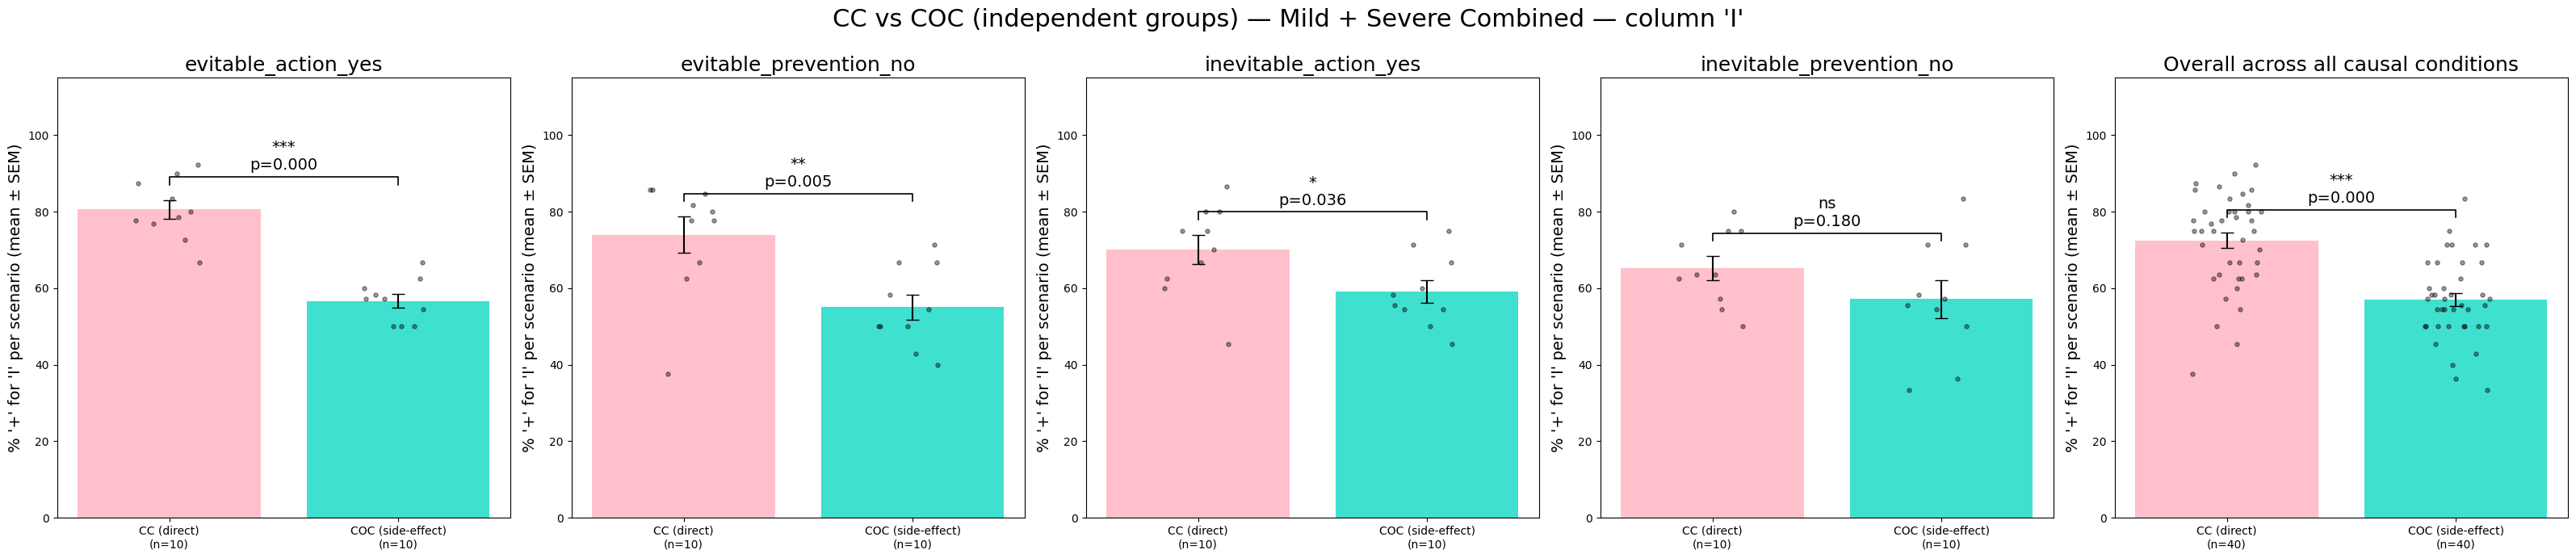

In [5]:
condition_pairs_cc_coc = [
    ("cc_evitable_action_yes_stories",    "coc_evitable_action_yes_stories",    "evitable_action_yes"),
    ("cc_evitable_prevention_no_stories", "coc_evitable_prevention_no_stories", "evitable_prevention_no"),
    ("cc_inevitable_action_yes_stories",  "coc_inevitable_action_yes_stories",  "inevitable_action_yes"),
    ("cc_inevitable_prevention_no_stories","coc_inevitable_prevention_no_stories","inevitable_prevention_no"),
]

# NOTE: CC and COC scenarios sharing a SID are independently-written dilemmas (matched only by
# profession, not content -- see Analysis 1B's note), and a check confirmed CC's own I+ event-labeling
# proportion for a given SID has no meaningful correlation with COC's (r=-0.05, ns). So CC and COC are
# treated as independent groups here (unpaired Welch's t-test, not the shared paired_proportion_barplots
# used by Analyses 2/3, whose pairs really do share identical dilemma text).
panel_vals = []
all_vals_a, all_vals_b = [], []
for cond_a, cond_b, panel_title in condition_pairs_cc_coc:
    vals_a = per_scenario_proportion(all_FRANKEN_df, cond_a, "I").values * 100
    vals_b = per_scenario_proportion(all_FRANKEN_df, cond_b, "I").values * 100
    panel_vals.append((vals_a, vals_b, panel_title))
    all_vals_a.extend(vals_a)
    all_vals_b.extend(vals_b)
panel_vals.append((np.array(all_vals_a), np.array(all_vals_b), "Overall across all causal conditions"))

fig, axs = plt.subplots(1, 5, figsize=(32, 7))
for ax, (vals_a, vals_b, panel_title) in zip(axs, panel_vals):
    p_val = ttest_ind(vals_a, vals_b, equal_var=False).pvalue
    means, sems, n = bar_dot_sem(ax, {"CC (direct)": vals_a, "COC (side-effect)": vals_b}, colors=["pink", "turquoise"])
    y_top = max(m + s for m, s in zip(means, sems)) + 4
    ax.plot([0, 0, 1, 1], [y_top, y_top + 2, y_top + 2, y_top], lw=1.2, c="black")
    ax.text(0.5, y_top + 3, f"{sig_stars(p_val)}\np={p_val:.3f}", ha="center", va="bottom", fontsize=14)
    ax.set_ylim(0, 115)
    ax.set_ylabel("% '+' for 'I' per scenario (mean ± SEM)")
    ax.yaxis.label.set_size(14)
    ax.set_title(panel_title, fontsize=18)

    print(f"[{panel_title}] CC n={len(vals_a)} mean={np.mean(vals_a):.1f}%, COC n={len(vals_b)} mean={np.mean(vals_b):.1f}%, Welch's t-test p={p_val:.4f}")

plt.suptitle("CC vs COC (independent groups) — Mild + Severe Combined — column 'I'", fontsize=22)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### **RESULT:** Hypothesis is true -- CC (mean-sharm) scenarios generate more I+ (intentional) events compared to COC.

## Analysis 1B -- Comparing *across* the CC and COC groups of scenarios; which group has more scenarios where the primary harm event is labelled I+?

### **Hypothesis:** The CC group of scenarios should have more scenarios where the primary harm event is labelled I+ compared to COC

[evitable_action_yes] CC I+ 4/10 (40.0%), COC I+ 0/10 (0.0%), Fisher's exact p=0.0867
[evitable_prevention_no] CC I+ 6/10 (60.0%), COC I+ 0/10 (0.0%), Fisher's exact p=0.0108
[inevitable_action_yes] CC I+ 1/10 (10.0%), COC I+ 0/10 (0.0%), Fisher's exact p=1.0000
[inevitable_prevention_no] CC I+ 2/10 (20.0%), COC I+ 1/10 (10.0%), Fisher's exact p=1.0000
[Overall across all causal conditions] CC I+ 13/40 (32.5%), COC I+ 1/40 (2.5%), Fisher's exact p=0.0007


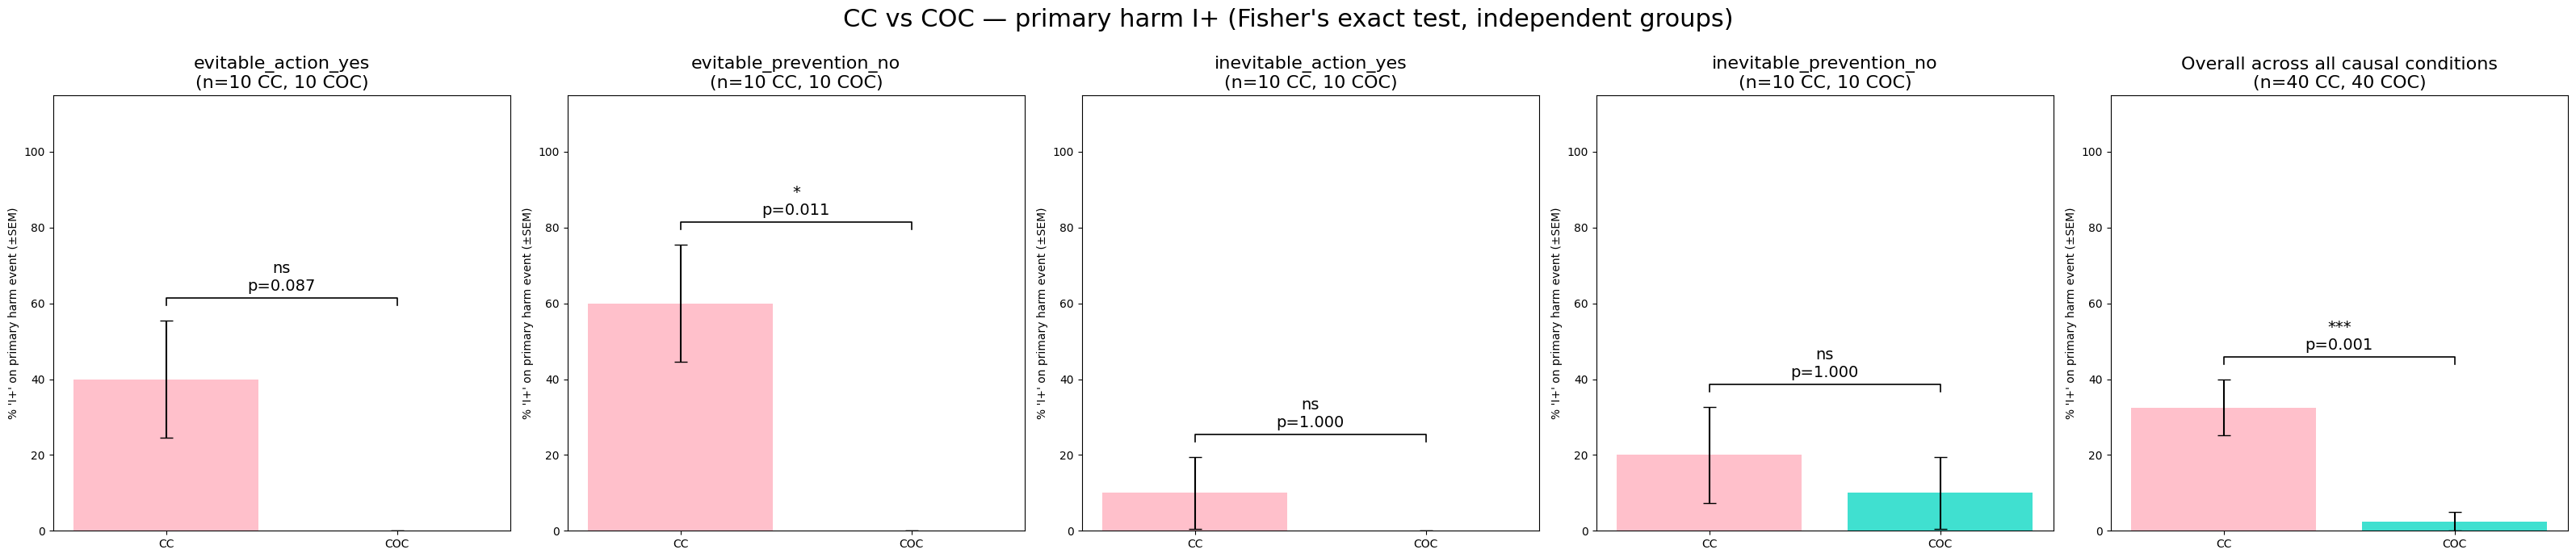

In [6]:
### Analysis 1B -- I+/- on primary harm event: CC vs COC (Fisher's exact test, independent groups), broken down into the same 4 evitability x action sub-panels + overall as Analysis 1A, for visual consistency -- only the "Overall" panel is really informative here since each sub-panel only has n=10 scenarios per group.
# NOTE: CC and COC scenarios sharing the same SID share a profession/persona but are otherwise
# independently-written dilemmas (e.g. SID 0 is "park renovation" for CC vs "bike lane system" for
# COC, but both are an architect) -- unlike the evitable/inevitable and action/prevention comparisons (Analyses 2/3), where the
# SAME dilemma is literally reused, just re-narrated with "I" vs "my colleague". So CC and COC are
# treated here as independent groups and compared with Fisher's exact test rather than a paired test.

primary_harm_df = pd.read_csv("mild_FRANKEN_primary_harm_df.csv")

primary_harm_df["structure"] = np.where(primary_harm_df["causal_condition"].str.startswith("cc"), "cc", "coc")
# NOTE: check "inevitable" first, it's a substring of "evitable"'s complement here so order matters
primary_harm_df["evitability"] = np.where(primary_harm_df["causal_condition"].str.contains("inevitable"), "inevitable", "evitable")
primary_harm_df["action"] = np.where(primary_harm_df["causal_condition"].str.contains("action_yes"), "action_yes", "prevention_no")
primary_harm_df["I_binary"] = primary_harm_df["I"].map({"+": 1, "-": 0})

subgroup_defs_1b = [
    ("evitable", "action_yes", "evitable_action_yes"),
    ("evitable", "prevention_no", "evitable_prevention_no"),
    ("inevitable", "action_yes", "inevitable_action_yes"),
    ("inevitable", "prevention_no", "inevitable_prevention_no"),
]

panel_data_1b = [(primary_harm_df[(primary_harm_df["evitability"] == evit) & (primary_harm_df["action"] == action)], title)
                  for evit, action, title in subgroup_defs_1b]
panel_data_1b.append((primary_harm_df, "Overall across all causal conditions"))

fig, axs = plt.subplots(1, 5, figsize=(32, 7))
for ax, (sub, panel_title) in zip(axs, panel_data_1b):
    cc_sub  = sub[sub["structure"] == "cc"]
    coc_sub = sub[sub["structure"] == "coc"]
    n_cc, n_coc = len(cc_sub), len(coc_sub)
    cc_pct, coc_pct = 100 * cc_sub["I_binary"].mean(), 100 * coc_sub["I_binary"].mean()

    table = [[n_cc - cc_sub["I_binary"].sum(), cc_sub["I_binary"].sum()],
             [n_coc - coc_sub["I_binary"].sum(), coc_sub["I_binary"].sum()]]
    _, p_val = fisher_exact(table)

    pcts = [cc_pct, coc_pct]
    sems = [100 * np.sqrt((p / 100) * (1 - p / 100) / n) for p, n in zip(pcts, [n_cc, n_coc])]
    ax.bar(["CC", "COC"], pcts, yerr=sems, capsize=6, color=["pink", "turquoise"], error_kw=dict(elinewidth=1.5))
    y_top = max(p + s for p, s in zip(pcts, sems)) + 4
    ax.plot([0, 0, 1, 1], [y_top, y_top + 2, y_top + 2, y_top], lw=1.2, c="black")
    ax.text(0.5, y_top + 3, f"{sig_stars(p_val)}\np={p_val:.3f}", ha="center", va="bottom", fontsize=14)
    ax.set_ylim(0, 115)
    ax.set_ylabel("% 'I+' on primary harm event (±SEM)")
    ax.set_title(f"{panel_title}\n(n={n_cc} CC, {n_coc} COC)", fontsize=16)

    print(f"[{panel_title}] CC I+ {int(cc_sub['I_binary'].sum())}/{n_cc} ({cc_pct:.1f}%), COC I+ {int(coc_sub['I_binary'].sum())}/{n_coc} ({coc_pct:.1f}%), Fisher's exact p={p_val:.4f}")

plt.suptitle("CC vs COC — primary harm I+ (Fisher's exact test, independent groups)", fontsize=22)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### **RESULT:** Hypothesis is true -- 13/40 CC scenarios have the primary harm event labelled I+, and only 1/40 COC scenarios has the primary harm event labelled I+.

## Analysis 1C -- Do the human intentionality ratings differ between CC and COC scenarios?

### Human `avg_intention_rating` comes from Exp2 (1-5 scale). CC and COC scenarios are treated as independent groups here (see Analysis 1B's note on why), comparing only the causal-structure manipulation (CC vs COC) directly.

### **Hypothesis:** The CC scenarios should have gotten higher intentionality ratings compared to COC

[evitable_action_yes] CC mean=1.992 (n=10), COC mean=2.146 (n=10), t=-1.667, p=0.1204
[evitable_prevention_no] CC mean=1.920 (n=10), COC mean=2.062 (n=10), t=-1.315, p=0.2049
[inevitable_action_yes] CC mean=2.202 (n=10), COC mean=2.381 (n=10), t=-1.865, p=0.0789
[inevitable_prevention_no] CC mean=2.287 (n=10), COC mean=2.600 (n=10), t=-2.603, p=0.0181
[Overall across all causal conditions] CC mean=2.100 (n=40), COC mean=2.297 (n=40), t=-3.025, p=0.0034


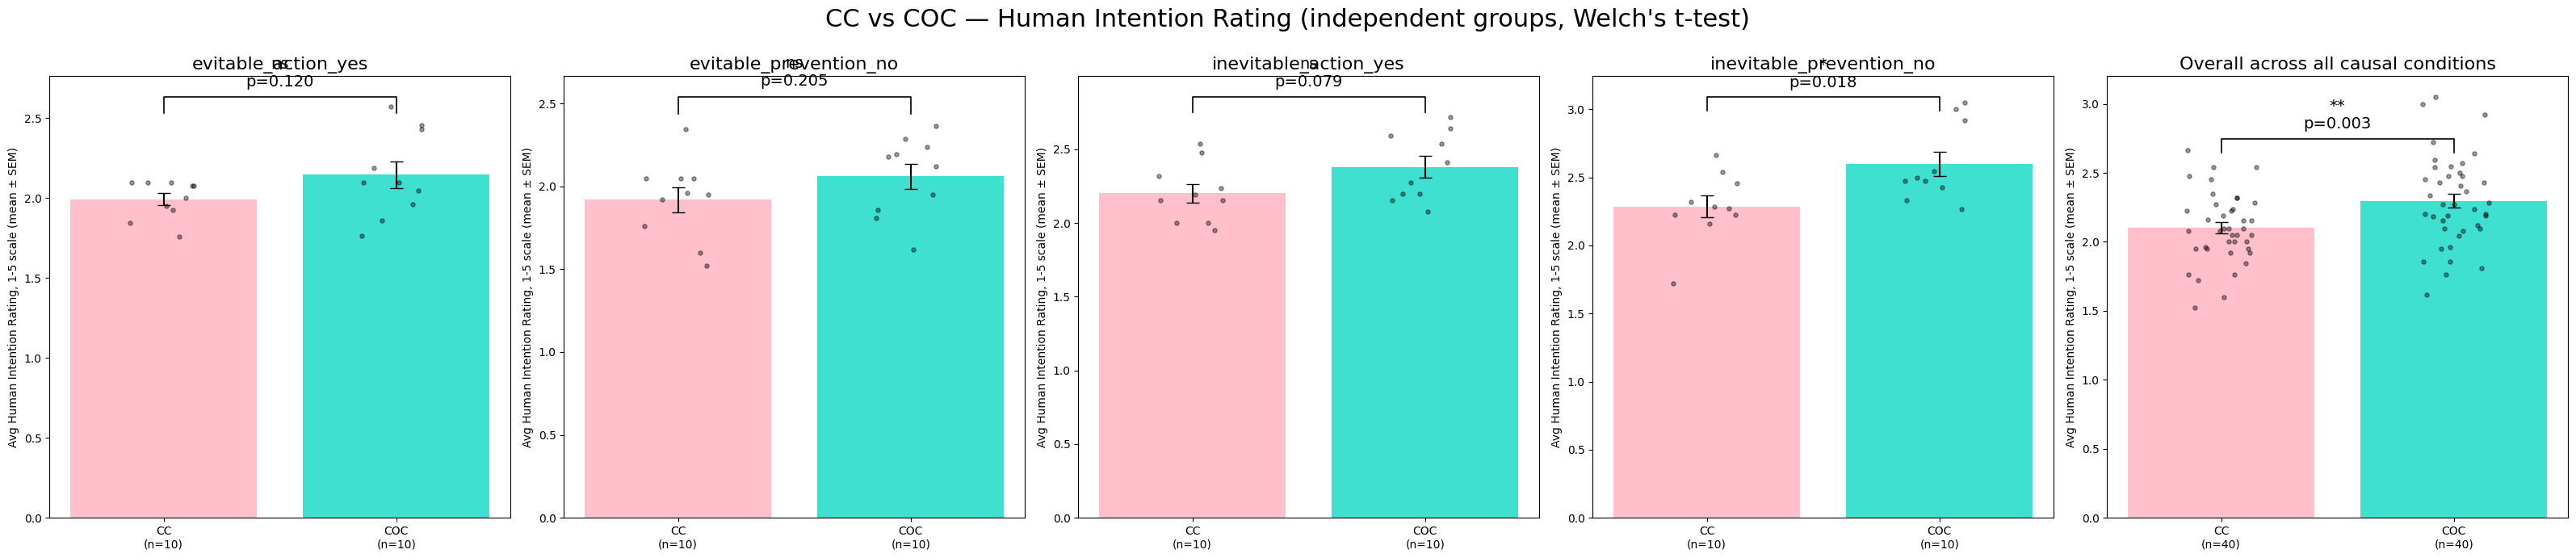

In [7]:
### Analysis 1C -- Human intention rating: CC vs COC (independent groups, Welch's t-test), broken down into the same 4 evitability x action sub-panels + overall as Analysis 1A, for visual consistency -- only the "Overall" panel is really informative here since each sub-panel only has n=10 scenarios per group.
# NOTE: unlike 1A, a check showed avg_intention_rating IS meaningfully correlated between matched CC/COC
# pairs (r=0.43, p=0.005) -- so treating them as independent groups here trades some statistical power
# for methodological consistency across Analysis 1 (a paired test would give p=0.0003 for Overall here,
# vs the unpaired p reported below). The conclusion doesn't change either way.

# Load and average human ratings
human_ratings_raw = pd.read_csv(Path().resolve() / "../../human_data/franken/exp2_moralperm-intent-rating/data_long_format.csv")
avg_int = (human_ratings_raw
           .groupby(["scenario_id", "causal_structure", "evitability", "action"])["intention_rating"]
           .mean().reset_index()
           .rename(columns={"intention_rating": "avg_intention_rating"}))

cc_ratings  = avg_int[avg_int["causal_structure"] == 0]
coc_ratings = avg_int[avg_int["causal_structure"] == 1]

# evitability/action here are numeric (0/1) per the Exp2 explainer -- map to the same string labels used in Analysis 1A/1B's sub-panels
subgroup_defs_1c = [
    (0, 0, "evitable_action_yes"),
    (0, 1, "evitable_prevention_no"),
    (1, 0, "inevitable_action_yes"),
    (1, 1, "inevitable_prevention_no"),
]

panel_data_1c = [(cc_ratings[(cc_ratings["evitability"] == evit) & (cc_ratings["action"] == action)]["avg_intention_rating"].values,
                   coc_ratings[(coc_ratings["evitability"] == evit) & (coc_ratings["action"] == action)]["avg_intention_rating"].values,
                   title)
                  for evit, action, title in subgroup_defs_1c]
panel_data_1c.append((cc_ratings["avg_intention_rating"].values, coc_ratings["avg_intention_rating"].values, "Overall across all causal conditions"))

fig, axs = plt.subplots(1, 5, figsize=(32, 7))
for ax, (cc_vals, coc_vals, panel_title) in zip(axs, panel_data_1c):
    n_cc, n_coc = len(cc_vals), len(coc_vals)
    t_stat, p_val = ttest_ind(cc_vals, coc_vals, equal_var=False)
    means, sems, _ = bar_dot_sem(ax, {"CC": cc_vals, "COC": coc_vals}, colors=["pink", "turquoise"])
    y_top = max(m + s for m, s in zip(means, sems)) + 0.3
    ax.plot([0, 0, 1, 1], [y_top, y_top + 0.1, y_top + 0.1, y_top], lw=1.2, c="black")
    ax.text(0.5, y_top + 0.15, f"{sig_stars(p_val)}\np={p_val:.3f}", ha="center", va="bottom", fontsize=14)
    ax.set_ylabel("Avg Human Intention Rating, 1-5 scale (mean ± SEM)")
    ax.set_title(f"{panel_title}", fontsize=16)

    print(f"[{panel_title}] CC mean={np.mean(cc_vals):.3f} (n={n_cc}), COC mean={np.mean(coc_vals):.3f} (n={n_coc}), t={t_stat:.3f}, p={p_val:.4f}")

plt.suptitle("CC vs COC — Human Intention Rating (independent groups, Welch's t-test)", fontsize=22)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### **RESULT:** Hypothesis is not true; COC (side-effect harm) scenarios get a very slightly higher intentionality rating than CC -- but it's a very slight difference.

# Analysis 2 -- Do "evitable" scenarios generate more causal events than "inevitable" scenarios?
### Comparing the per-scenario proportion of "C+" events between Evitable and Inevitable counterparts of the causal conditions (also checking overall across all)
### **Commonsense hypothesis =** Evitable scenarios should have more events with more "control" over the outcome than inevitable, i.e. get more C+'s than inevitable scenarios.

### Same scenario-level, paired-by-SID improvement as Analysis 1 (paired here by SID x causal_structure x action, varying only evitability).

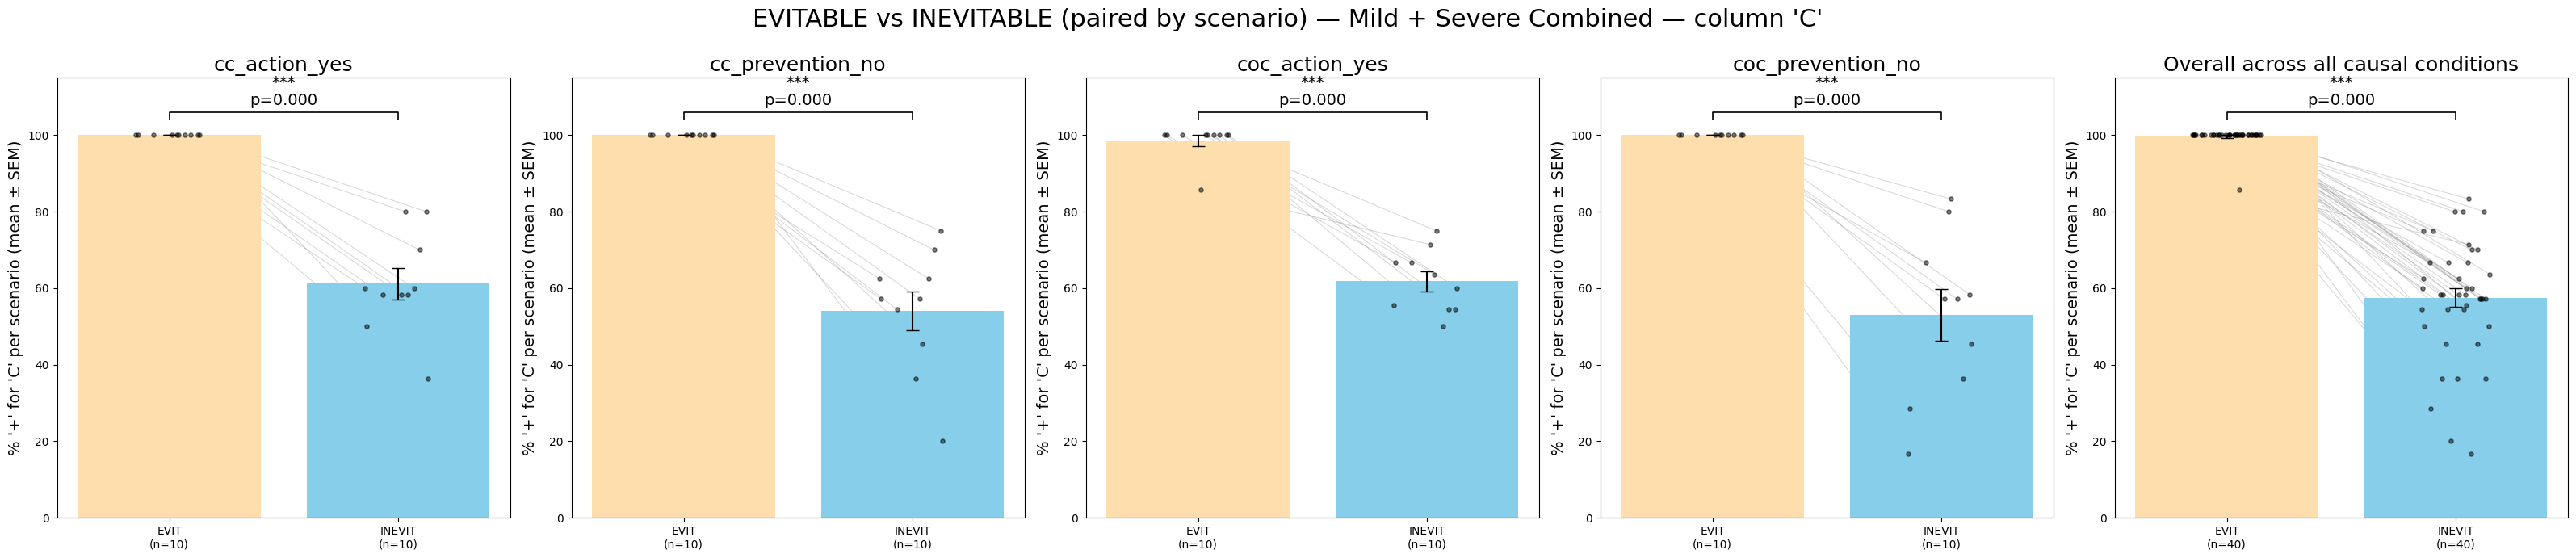

In [8]:
condition_pairs_evit_inevit = [
    ("cc_evitable_action_yes_stories",     "cc_inevitable_action_yes_stories",     "cc_action_yes"),
    ("cc_evitable_prevention_no_stories",  "cc_inevitable_prevention_no_stories",  "cc_prevention_no"),
    ("coc_evitable_action_yes_stories",    "coc_inevitable_action_yes_stories",    "coc_action_yes"),
    ("coc_evitable_prevention_no_stories", "coc_inevitable_prevention_no_stories", "coc_prevention_no"),
]

# paired_proportion_barplots(mild_FRANKEN_df, "Mild Harm/Mild Good", column="C",
#                             condition_pairs=condition_pairs_evit_inevit, pair_labels=("EVIT", "INEV"),
#                             colors=["navajowhite", "skyblue"],
#                             suptitle="EVITABLE vs INEVITABLE (paired by scenario) — Mild Harm/Mild Good — column 'C'")
# paired_proportion_barplots(severe_FRANKEN_df, "Severe Harm/Very Good", column="C",
#                             condition_pairs=condition_pairs_evit_inevit, pair_labels=("EVIT", "INEV"),
#                             colors=["navajowhite", "skyblue"],
#                             suptitle="EVITABLE vs INEVITABLE (paired by scenario) — Severe Harm/Very Good — column 'C'")
paired_proportion_barplots(all_FRANKEN_df, "Mild + Severe Combined", column="C",
                            condition_pairs=condition_pairs_evit_inevit, pair_labels=("EVIT", "INEVIT"),
                            colors=["navajowhite", "skyblue"],
                            suptitle="EVITABLE vs INEVITABLE (paired by scenario) — Mild + Severe Combined — column 'C'")

### **RESULT:** Hypothesis is true -- Evitable scenarios generate more C+ (causal) events compared to inevitable scenarios.

# Analysis 3 -- Do "commission" scenarios generate more intentional events than "omission" scenarios?
### Comparing the per-scenario proportion of "I+" events between action_yes (commission) and prevention_no (omission) counterparts of the causal conditions (also checking overall across all)
### **Commonsense hypothesis =** Explicitly acting towards a harm feels more intentional than letting it happen passively, so they should get more I+ events.

### Same scenario-level, paired-by-SID improvement as Analyses 1 and 2 (paired here by SID x causal_structure x evitability, varying only action).

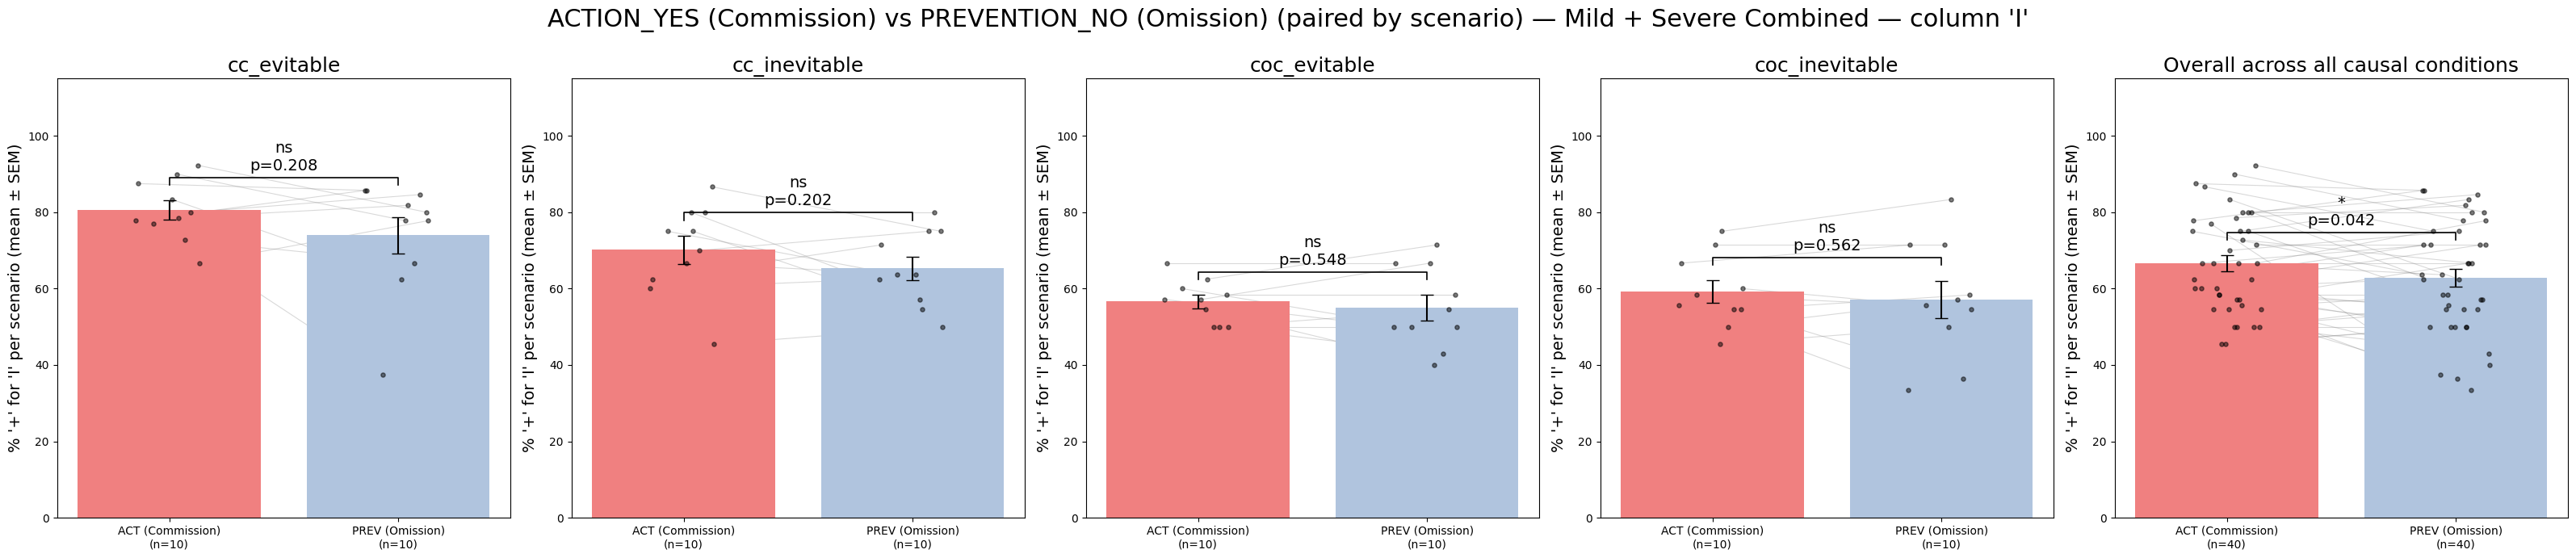

In [9]:
condition_pairs_action_prevention = [
    ("cc_evitable_action_yes_stories",    "cc_evitable_prevention_no_stories",    "cc_evitable"),
    ("cc_inevitable_action_yes_stories",  "cc_inevitable_prevention_no_stories",  "cc_inevitable"),
    ("coc_evitable_action_yes_stories",   "coc_evitable_prevention_no_stories",   "coc_evitable"),
    ("coc_inevitable_action_yes_stories", "coc_inevitable_prevention_no_stories", "coc_inevitable"),
]

# paired_proportion_barplots(mild_FRANKEN_df, "Mild Harm/Mild Good", column="I",
#                             condition_pairs=condition_pairs_action_prevention, pair_labels=("ACT", "PREV"),
#                             colors=["lightcoral", "lightsteelblue"],
#                             suptitle="ACTION_YES (Commission) vs PREVENTION_NO (Omission) (paired by scenario) — Mild Harm/Mild Good — column 'I'")
# paired_proportion_barplots(severe_FRANKEN_df, "Severe Harm/Very Good", column="I",
#                             condition_pairs=condition_pairs_action_prevention, pair_labels=("ACT", "PREV"),
#                             colors=["lightcoral", "lightsteelblue"],
#                             suptitle="ACTION_YES (Commission) vs PREVENTION_NO (Omission) (paired by scenario) — Severe Harm/Very Good — column 'I'")
paired_proportion_barplots(all_FRANKEN_df, "Mild + Severe Combined", column="I",
                            condition_pairs=condition_pairs_action_prevention, pair_labels=("ACT (Commission)", "PREV (Omission)"),
                            colors=["lightcoral", "lightsteelblue"],
                            suptitle="ACTION_YES (Commission) vs PREVENTION_NO (Omission) (paired by scenario) — Mild + Severe Combined — column 'I'")

### **RESULT:** Hypothesis is not true -- there is not a significant difference in proportion of I+ events generated between ACT (comission) and PREV (omission) scenarios.

# Analysis 4 -- Do "severe" scenarios get events with more extreme utility scores than "mild" scenarios?
### Comparing the utility score distributions between mild and severe counterparts of each causal condition (also checking overall)
### **Commonsense hypothesis =** The "severe_harm_very_good" utility distributions SHOULD be more negative (on the harm side) AND more positive (on the good side) overall than the "mild_harm_mild_good" utility distributions.

#### **How do we pick one utility score to represent a scenario?**
##### We need to pick the utility score of one event for a scenario -- this event should be the "primary harm" (or, for the good-magnitude test below, "primary good") event.
1. ##### **Quantitative way to do it:** look at the utility score ascribed by the annotator to all events, pick the most negative (harm) or most positive (good) score
    - ##### Each identified entity gets its own utility score, so there are multiple sub-strategies:

        - ##### **Simplest:** pick the single most extreme utility score **regardless of entity** across all events of a scenario
        - ##### **"I"-only:** pick the single most extreme utility score **assigned to "I"** across all events of a scenario, i.e., where I (agent) was most affected
        - ##### **Non-"I"-only:** pick the single most extreme utility score **not assigned to "I"** across all events of a scenario, i.e., where some patient was most affected

2. ##### **Qualitative way to do it:** look at all events, pick the most salient harm event by hand, then either pick the utility score ascribed to "I" or the worst-affected non-"I" entity.

##### **Below, only the Quantitative, "simplest" strategy is implemented** for both the harm side (most-negative utility) and the good side (most-positive utility).

##### Change the utility-picking strategies here:

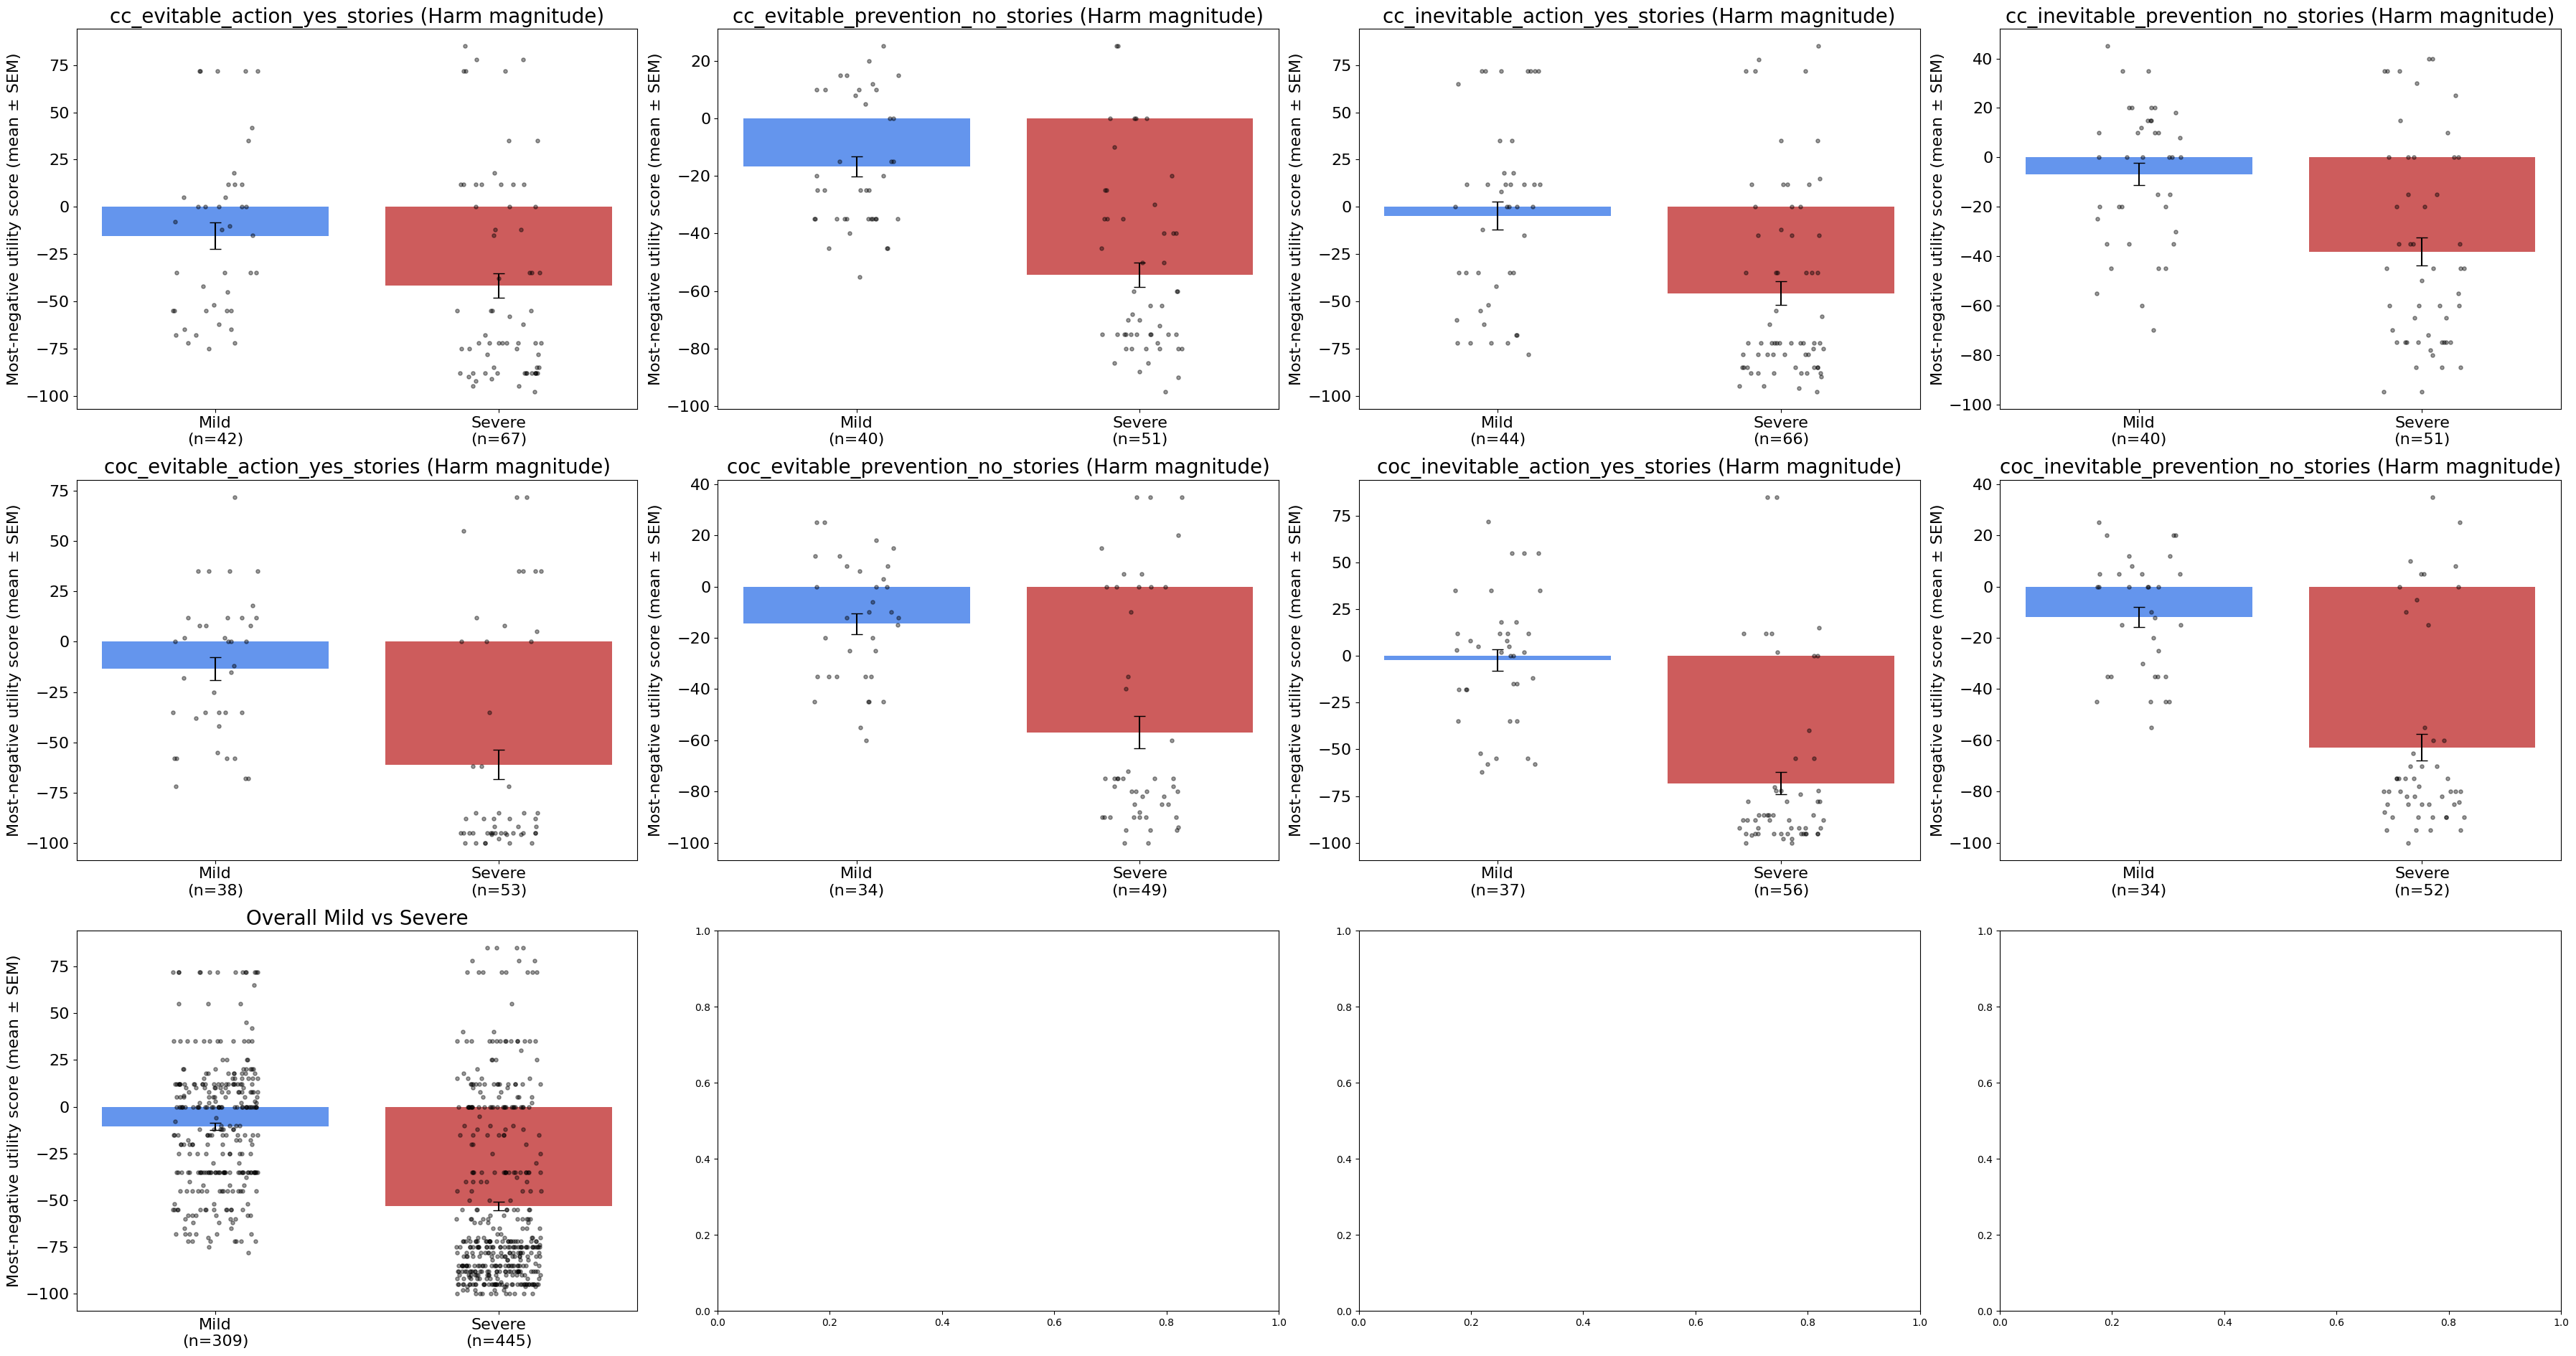

In [10]:
create_utility_bar_dot_plots(all_FRANKEN_df, "(Harm magnitude)", extract_min_utility, "Most-negative utility score (mean ± SEM)")

### **RESULT:**

- ### The utility scores look more negative-shifted in general for severe scenarios in general.

- ### This tell us that the "severe" scenarios' worst scores are more negative than "mild" scenarios' worst scores. (So "severe_harm" is indeed more severe than "mild_harm"). 

- ### Is "_very_good" indeed more good than "_mild_good" though? We don't know that part. We could know if we compared the most positive event utility scores b/w severe and mild scenarios instead (which would be the opposite of a primary harm), but it doesn't really matter as a thing to check. I suspect it is true.

### Is the severe utility distribution **statistically significantly** more negative (harm) than the mild distribution? One-sided t-tests across the 9 tests (8 causal conditions + overall) within each of the two utility directions:

In [11]:
print("Harm magnitude (most-negative utility): one-sided test that severe < mild, across 9 tests:")
harm_t_test_results = perform_t_tests(all_FRANKEN_df, extract_min_utility, alternative="less")
pprint.pprint(harm_t_test_results)

# print("\nGood magnitude (most-positive utility): one-sided test that severe > mild, across 9 tests:")
# good_t_test_results = perform_t_tests(all_FRANKEN_df, extract_max_utility, alternative="greater")
# pprint.pprint(good_t_test_results)

Harm magnitude (most-negative utility): one-sided test that severe < mild, across 9 tests:
{'cc_evitable_action_yes_stories': {'p_value': np.float64(0.004783778597584393),
                                    't_stat': np.float64(-2.638578871880066)},
 'cc_evitable_prevention_no_stories': {'p_value': np.float64(2.7686114971040647e-09),
                                       't_stat': np.float64(-6.454857107887428)},
 'cc_inevitable_action_yes_stories': {'p_value': np.float64(2.4262915885414675e-05),
                                      't_stat': np.float64(-4.233308022051441)},
 'cc_inevitable_prevention_no_stories': {'p_value': np.float64(4.159373308260511e-05),
                                         't_stat': np.float64(-4.124974928559832)},
 'coc_evitable_action_yes_stories': {'p_value': np.float64(3.7640597262104173e-06),
                                     't_stat': np.float64(-4.757322749931924)},
 'coc_evitable_prevention_no_stories': {'p_value': np.float64(8.544003243604259e

### Note: t-stat being negative means that severe scores are indeed more negative than mild.

### **RESULT:** The severe utility score distributions are (basically) always statistically significantly more negative than mild counterpart -- there is a consistent diference in utility score distribution between severe and mild scenarios

# Analysis 5 -- Do scenarios deemed more intentional by the annotator (in some way) get rated as more intentional by humans too?

### Humans rated intentionality on a SCENARIO-level, annotator gives "I" labels on an EVENT-level. 

### There are three ways we can try to get a scenario-level "I" label for a scenario from the annotator -- take the label of the primary-harm event (5A), take the label of the most-negative utility event (5B), or take the label of the majority of all generated events (5C).

### We split the scenarios into I+ and I- groups based on the these three strategies and compare the avg human intentionality rating given to each group -- we would like to see a significant difference in avg. human rating between the two.

## Analysis 5A -- I+/- vs Human Intentionality Rating using the QUALITATIVE, hand-picked primary harm event
### (stored in `mild_FRANKEN_primary_harm_df.csv`).

### Note: `avg_intention_rating` is a scenario-level human judgment, while the I+/- label compared against it here is for one specific extracted event (the hand-picked primary harm)

Qualitative pick DF: 80 rows | I+: 14, I-: 66


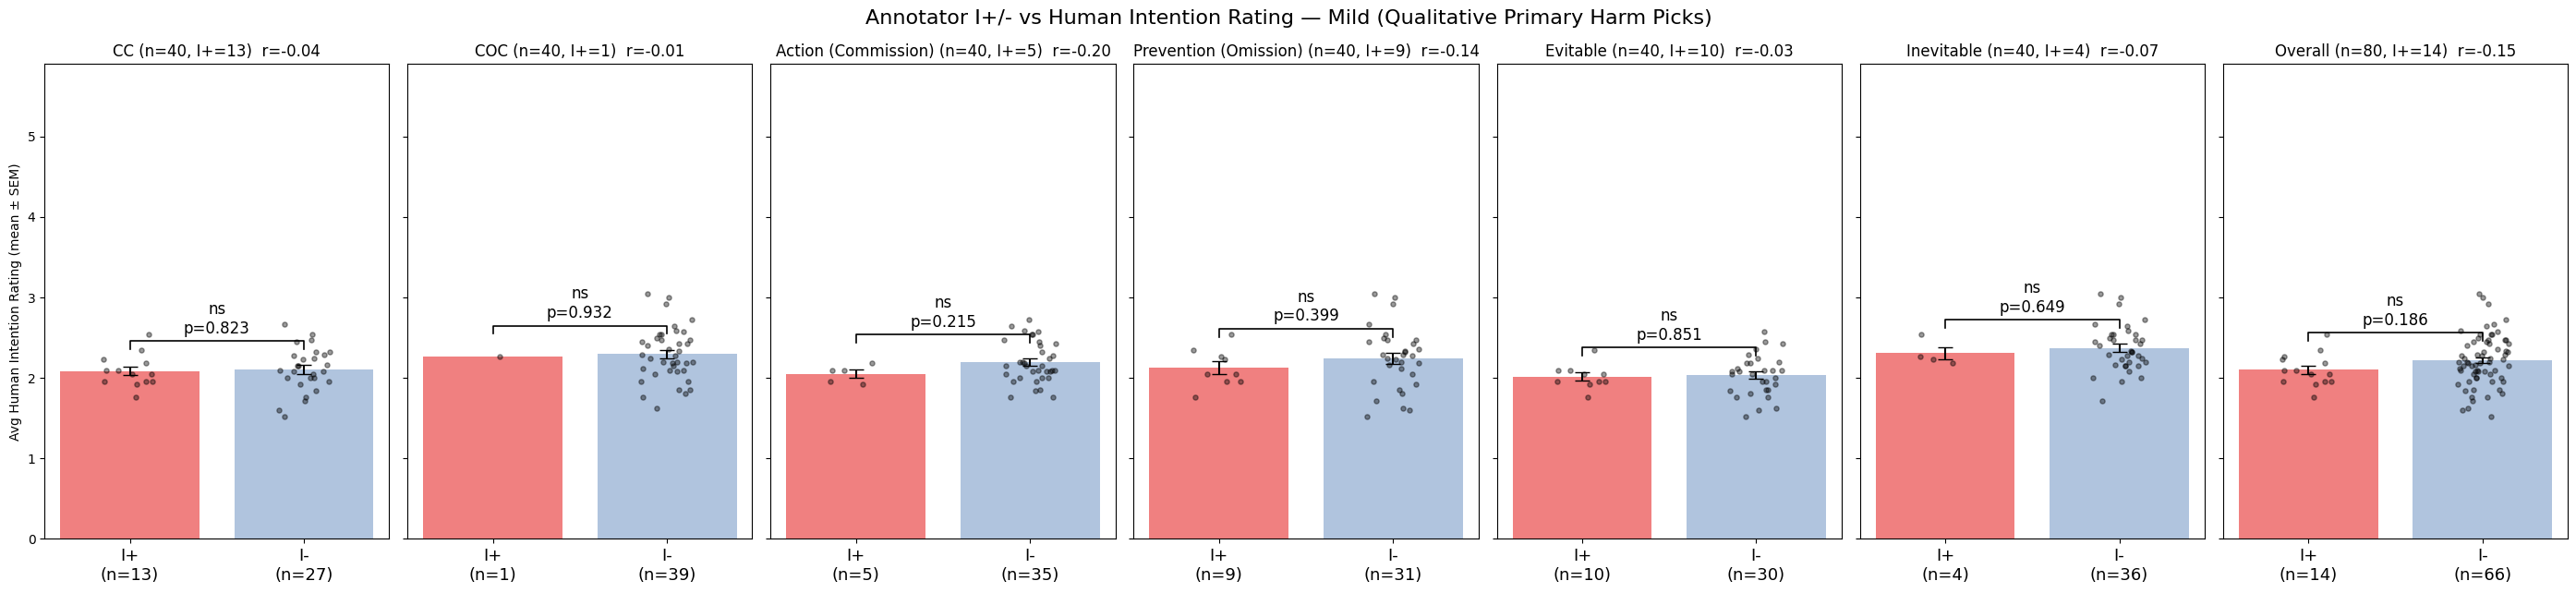

Correlation results — qualitative primary harm picks:
{'Action (Commission)': {'n_I+': 5,
                         'n_scenarios': 40,
                         'p_I_intention': 0.21469080331331566,
                         'r_I_intention (point-biserial)': -0.2005417925216616},
 'CC': {'n_I+': 13,
        'n_scenarios': 40,
        'p_I_intention': 0.823265262878338,
        'r_I_intention (point-biserial)': -0.036458680238090554},
 'COC': {'n_I+': 1,
         'n_scenarios': 40,
         'p_I_intention': 0.9322427293032672,
         'r_I_intention (point-biserial)': -0.013882987755361838},
 'Evitable': {'n_I+': 10,
              'n_scenarios': 40,
              'p_I_intention': 0.8506647575782493,
              'r_I_intention (point-biserial)': -0.03073576848171877},
 'Inevitable': {'n_I+': 4,
                'n_scenarios': 40,
                'p_I_intention': 0.6489107320335302,
                'r_I_intention (point-biserial)': -0.07424011716241155},
 'Overall': {'n_I+': 14,
          

In [12]:
import ast

# mild_FRANKEN_primary_harm_df.csv already has the picked event's I, utility, and
# avg_intention_rating as scalar values -- load directly, no withhuman_df lookup needed
qualitative_scenario_df = pd.read_csv("mild_FRANKEN_primary_harm_df.csv").dropna()
qualitative_scenario_df["I_binary"] = qualitative_scenario_df["I"].map({"+": 1, "-": 0})
qualitative_scenario_df["I_label"]  = qualitative_scenario_df["I"].map({"+": "I+", "-": "I-"})

print(f"Qualitative pick DF: {len(qualitative_scenario_df)} rows | "
      f"I+: {(qualitative_scenario_df['I'] == '+').sum()}, I-: {(qualitative_scenario_df['I'] == '-').sum()}")

correlation_results_qualitative = intentionality_by_I_label_plot(
    qualitative_scenario_df,
    suptitle="Annotator I+/- vs Human Intention Rating — Mild (Qualitative Primary Harm Picks)",
    print_label="qualitative primary harm picks",
)

### **RESULT:** Annotator I+/- labelling does NOT split scenarios cleanly into human high/low intentionality rating -- the avg human intentionality rating between both groups (I+ scenarios and I- scenarios; based on label of *primary harm* event) is basically the same.

## Analysis 5B -- Same analysis but using the MOST-NEGATIVE UTILITY event as the chosen event per scenario (for direct comparison with Analysis 5A)

No NaN values found in I column.
Most-negative utility DF: 79 rows | I+: 23, I-: 56


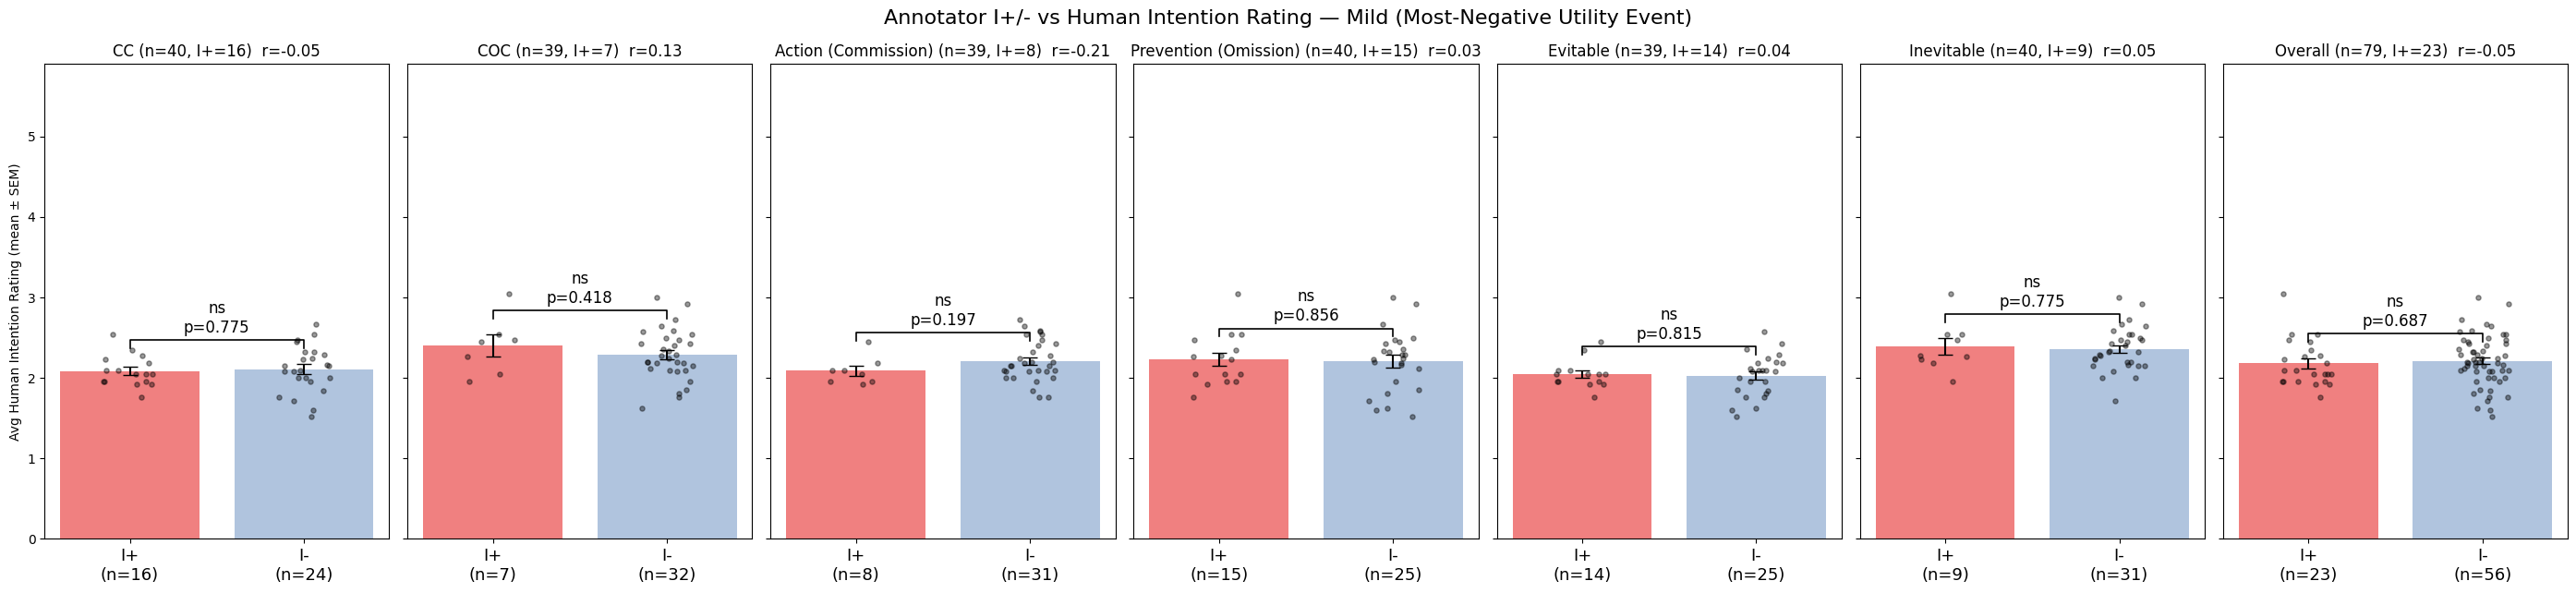

Correlation results — most-negative utility event:
{'Action (Commission)': {'n_I+': 8,
                         'n_scenarios': 39,
                         'p_I_intention': 0.19716695555322916,
                         'r_I_intention (point-biserial)': -0.21104296347044627},
 'CC': {'n_I+': 16,
        'n_scenarios': 40,
        'p_I_intention': 0.7745811193663058,
        'r_I_intention (point-biserial)': -0.04673924082577358},
 'COC': {'n_I+': 7,
         'n_scenarios': 39,
         'p_I_intention': 0.4180558132097463,
         'r_I_intention (point-biserial)': 0.13343149554700043},
 'Evitable': {'n_I+': 14,
              'n_scenarios': 39,
              'p_I_intention': 0.8148710564248427,
              'r_I_intention (point-biserial)': 0.038739847868753695},
 'Inevitable': {'n_I+': 9,
                'n_scenarios': 40,
                'p_I_intention': 0.774690119968617,
                'r_I_intention (point-biserial)': 0.04671603797053282},
 'Overall': {'n_I+': 23,
             'n_

In [13]:
import ast

# Load compact CSV (one row per scenario, list columns stored as strings)
compact_df = pd.read_csv("mild_FRANKEN_compact_df.csv")
compact_df = compact_df[~compact_df['I'].str.contains(r'\bnan\b', na=False)]

# utility is a list of dicts -- ast.literal_eval is fine
compact_df["utility_list"] = compact_df["utility"].apply(ast.literal_eval)
compact_df["I_list"] = compact_df["I"].apply(ast.literal_eval)

nan_rows = compact_df[compact_df.apply(lambda r: len(r["I_list"]) < len(r["utility_list"]), axis=1)]
if len(nan_rows):
    print(f"WARNING: {len(nan_rows)} scenario(s) have NaN in their I column (skipped in I_list):")
    print(nan_rows[["SID", "causal_condition", "I"]].to_string(index=False))
else:
    print("No NaN values found in I column.")

# For each scenario, pick the event with the most negative utility score
rows = []
for _, row in compact_df.iterrows():
    scores  = [extract_utility_score(u) for u in row["utility_list"]]
    min_idx = int(np.argmin(scores))
    rows.append({
        "SID": row["SID"],
        "causal_condition": row["causal_condition"],
        "I": row["I_list"][min_idx] if min_idx < len(row["I_list"]) else float("nan"),
        "avg_intention_rating": row["avg_intention_rating"],
        "avg_permissibility_rating": row["avg_permissibility_rating"],
    })

most_negative_df = pd.DataFrame(rows).dropna(subset=["avg_intention_rating"]).reset_index(drop=True)
most_negative_df["I_binary"] = most_negative_df["I"].map({"+": 1, "-": 0})
most_negative_df["I_label"]  = most_negative_df["I"].map({"+": "I+", "-": "I-"})

print(f"Most-negative utility DF: {len(most_negative_df)} rows | "
      f"I+: {(most_negative_df['I'] == '+').sum()}, I-: {(most_negative_df['I'] == '-').sum()}")

correlation_results_mn = intentionality_by_I_label_plot(
    most_negative_df,
    suptitle="Annotator I+/- vs Human Intention Rating — Mild (Most-Negative Utility Event)",
    print_label="most-negative utility event",
)

### **RESULT:** Annotator I+/- labelling does NOT split scenarios cleanly into human high/low intentionality rating -- the avg human intentionality rating between both groups (I+ scenarios and I- scenarios; based on label of *most-negative utility* event) is basically the same.

## Analysis 5C -- Same analysis but using a MAJORITY VOTE across all of a scenario's events as the representative "I" label (I+ if more than 50% of events are labeled I+, else I-; exact ties at 50% count as I-)

Majority-vote DF: 79 rows | I+: 50, I-: 29 (17 scenarios tied at exactly 50% I+, counted as I-)


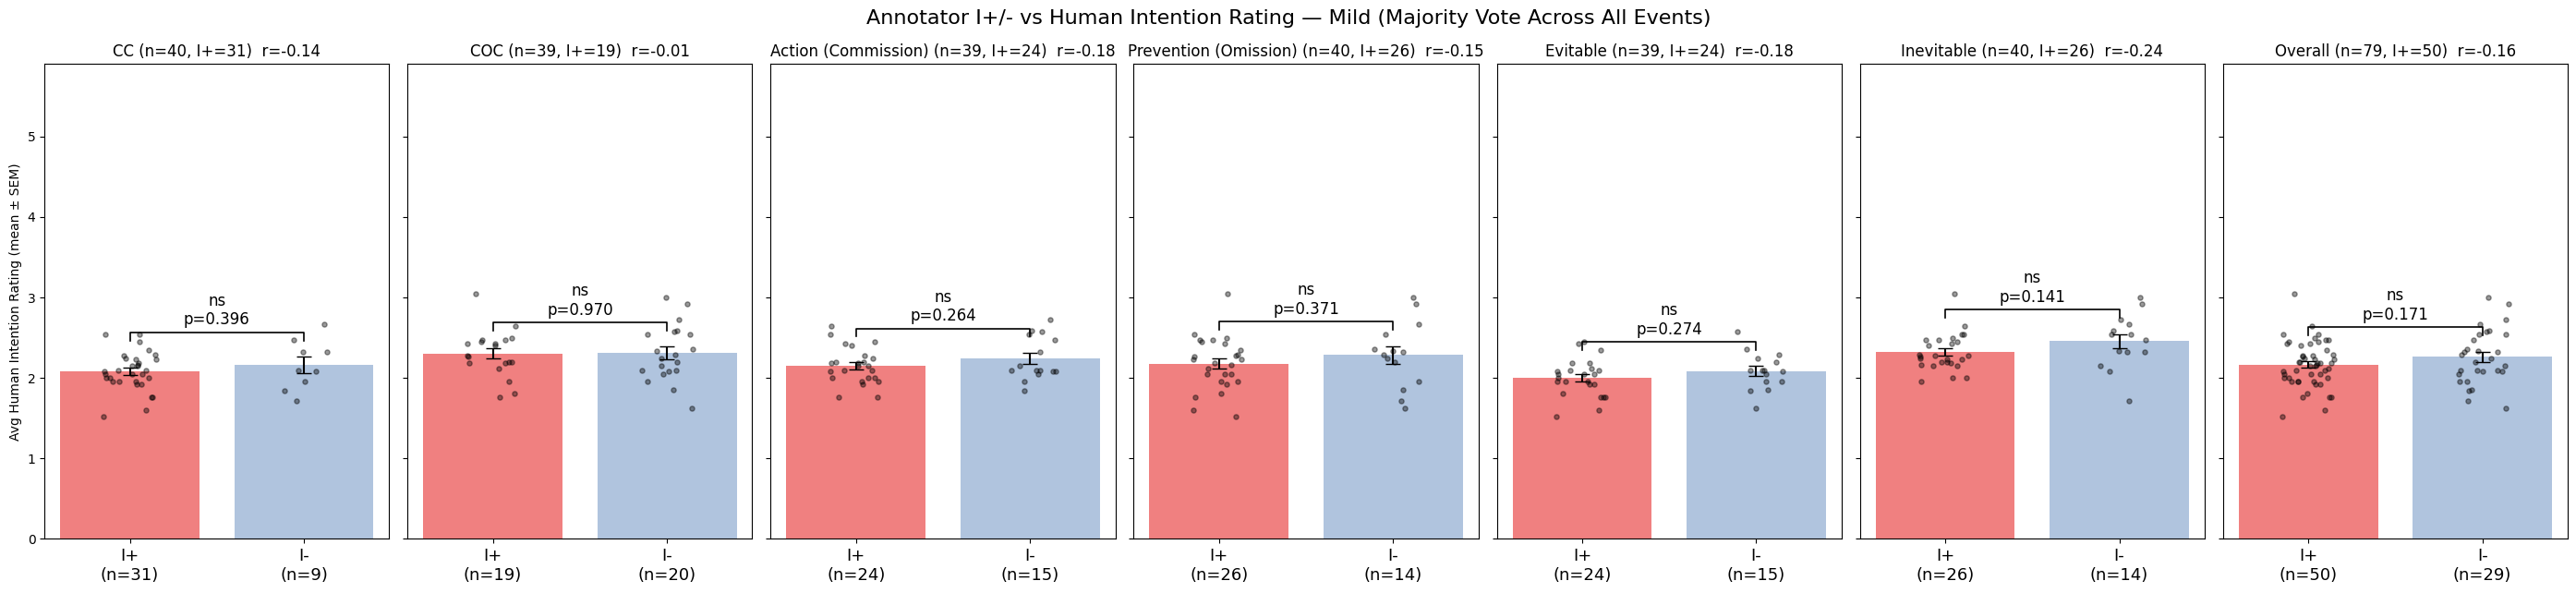

Correlation results — majority vote across all events:
{'Action (Commission)': {'n_I+': 24,
                         'n_scenarios': 39,
                         'p_I_intention': 0.2640066629086231,
                         'r_I_intention (point-biserial)': -0.18330172079646725},
 'CC': {'n_I+': 31,
        'n_scenarios': 40,
        'p_I_intention': 0.39571473379887284,
        'r_I_intention (point-biserial)': -0.1380182149952067},
 'COC': {'n_I+': 19,
         'n_scenarios': 39,
         'p_I_intention': 0.9695048904543835,
         'r_I_intention (point-biserial)': -0.006327392240155734},
 'Evitable': {'n_I+': 24,
              'n_scenarios': 39,
              'p_I_intention': 0.27363170323971603,
              'r_I_intention (point-biserial)': -0.1797133363920955},
 'Inevitable': {'n_I+': 26,
                'n_scenarios': 40,
                'p_I_intention': 0.14084456687832553,
                'r_I_intention (point-biserial)': -0.23703025324430516},
 'Overall': {'n_I+': 50,
     

In [14]:
import ast

# Load compact CSV (one row per scenario, list columns stored as strings)
compact_df = pd.read_csv("mild_FRANKEN_compact_df.csv")
compact_df = compact_df[~compact_df['I'].str.contains(r'\bnan\b', na=False)]
compact_df["I_list"] = compact_df["I"].apply(ast.literal_eval)

# Representative "I" label for a scenario = majority vote across all its events: I+ if strictly
# more than 50% of events are labeled I+, else I- (exact ties at 50% count as I-)
compact_df["prop_I_plus"] = compact_df["I_list"].apply(lambda lst: sum(1 for x in lst if x == "+") / len(lst))
compact_df["I_majority"] = compact_df["prop_I_plus"].apply(lambda p: "+" if p > 0.5 else "-")

majority_df = compact_df.dropna(subset=["avg_intention_rating"]).reset_index(drop=True)
majority_df["I_binary"] = majority_df["I_majority"].map({"+": 1, "-": 0})
majority_df["I_label"]  = majority_df["I_majority"].map({"+": "I+", "-": "I-"})

n_ties = int((majority_df["prop_I_plus"] == 0.5).sum())
print(f"Majority-vote DF: {len(majority_df)} rows | "
      f"I+: {(majority_df['I_majority'] == '+').sum()}, I-: {(majority_df['I_majority'] == '-').sum()} "
      f"({n_ties} scenarios tied at exactly 50% I+, counted as I-)")

correlation_results_majority = intentionality_by_I_label_plot(
    majority_df,
    suptitle="Annotator I+/- vs Human Intention Rating — Mild (Majority Vote Across All Events)",
    print_label="majority vote across all events",
)

### **RESULT:** Same as 5A/5B -- Annotator I+/- labelling does NOT split scenarios cleanly into human high/low intentionality rating, even when the representative label is a majority vote across all of a scenario's events rather than one picked event (Overall: r=-0.16, p=0.17, ns).

# Analysis 6 -- Does Exp2 permissibility rating correlate with Exp1 harm and good rating?
### Regressing Exp2's `avg_permissibility_rating` on Exp1's `avg_harm_rating` and `avg_good_rating` (n=40 scenarios with both ratings: mild, action_yes causal conditions only).
### **Commonsense hypothesis =** A worse harm should make the action less permissible, and a bigger benefit should make it more permissible -- i.e. `avg_permissibility_rating` should rise with both `avg_harm_rating` and `avg_good_rating` (both share the same 1-7 Likert scale where 7 = most good outcome).


Bivariate: permissibility vs avg_harm_rating: r=-0.208, p=0.1989  ns
Bivariate: permissibility vs avg_good_rating:  r=0.284, p=0.0754  ns


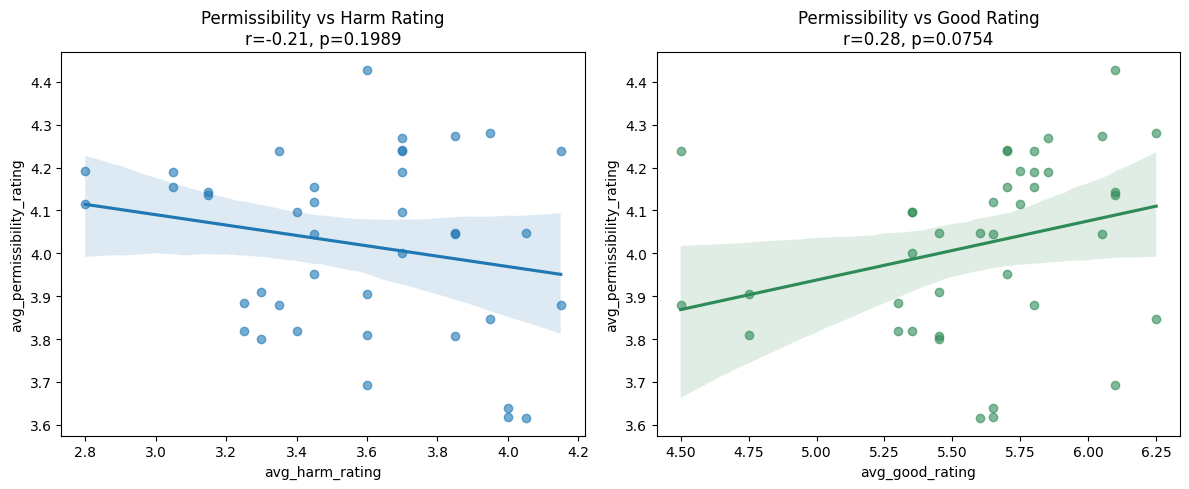

In [15]:
import statsmodels.formula.api as smf

exp1exp2_df = pd.read_csv("all_FRANKEN_exp1exp2matched_df.csv")

model = smf.ols("avg_permissibility_rating ~ avg_harm_rating + avg_good_rating", data=exp1exp2_df).fit()
# print(model.summary())

r_harm, p_harm = pearsonr(exp1exp2_df["avg_harm_rating"], exp1exp2_df["avg_permissibility_rating"])
r_good, p_good = pearsonr(exp1exp2_df["avg_good_rating"], exp1exp2_df["avg_permissibility_rating"])
print(f"\nBivariate: permissibility vs avg_harm_rating: r={r_harm:.3f}, p={p_harm:.4f}  {sig_stars(p_harm)}")
print(f"Bivariate: permissibility vs avg_good_rating:  r={r_good:.3f}, p={p_good:.4f}  {sig_stars(p_good)}")

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.regplot(data=exp1exp2_df, x="avg_harm_rating", y="avg_permissibility_rating", ax=axs[0], scatter_kws={"alpha": 0.6})
axs[0].set_title(f"Permissibility vs Harm Rating\nr={r_harm:.2f}, p={p_harm:.4f}")
sns.regplot(data=exp1exp2_df, x="avg_good_rating", y="avg_permissibility_rating", ax=axs[1], scatter_kws={"alpha": 0.6}, color="seagreen")
axs[1].set_title(f"Permissibility vs Good Rating\nr={r_good:.2f}, p={p_good:.4f}")
plt.tight_layout()
plt.show()

### **RESULT:** Hypothesis is not true -- there is no significant correlation between Exp2 permissibility rating and Exp 1 goodness ratings (for now).